## Set-up

In [ ]:
!pip install -U datasets
!pip install ray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 19.0 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12

In [ ]:
import datasets
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
import random
import numpy as np
from datasets import Dataset

# Ensure reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
# Clear PyTorch GPU cache
torch.cuda.empty_cache()

# Training set parameters
fraction_positives = 1
fraction_positives_in_test = 0.1        # percentage of positives in test set
fraction_remaining_unlabeled = 0.2      # percentage to keep of unlabled for reconstructing training set

# Model parameters
model_id = "xlm-roberta-large"
max_token_length = None                 # None uses max model allows

# Hyperparameter tuning
fraction_positives_for_tuning = 1
n_trials_ray = 20
n_cpu_ray = 2
n_gpu_ray = 1                           # For colab, 1 GPU max

# Prediciton parameters
fraction_unlabeled_for_prediction = 0.1

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# Load the data
gen_to_mine = pd.read_feather("./drive/MyDrive/Colab Notebooks/gen_to_mine.feather")

# Discard any missing values in text_mining_descriptiong
gen_to_mine = gen_to_mine.dropna(subset=['text_mining_description'])

# Initial classification

## Construct training set with random negatives

In [ ]:
# Filter out positive as ones with , mining and unlabeled samples
positive = gen_to_mine[
    (gen_to_mine['is_gender'] == True) &
    ~(gen_to_mine['gen_keywords'].apply(lambda x: isinstance(x, (list, np.ndarray)) and len(x) == 1 and x[0] == 'woman'))
    ].copy()
unlabeled = gen_to_mine[gen_to_mine['is_gender'] == False].copy()

# Sample randomly fraction_positives for positives
positive = positive.sample(frac=fraction_positives, random_state=SEED)

In [ ]:
# ---------------- Stratified sampling from unlabeled --------------------------
# Create length bins according to language and length of text_mining_description
positive.loc[:, 'length_bin'] = pd.cut(positive['text_mining_description'].str.len(), bins=6, labels=False, include_lowest=True)
unlabeled.loc[:, 'length_bin'] = pd.cut(unlabeled['text_mining_description'].str.len(), bins=6, labels=False, include_lowest=True)

# Create joint stratum
positive.loc[:, 'stratum'] = positive['language'].astype(str) + "_" + positive['length_bin'].astype(str)
unlabeled.loc[:, 'stratum'] = unlabeled['language'].astype(str) + "_" + unlabeled['length_bin'].astype(str)

# Calculate stratum distribution in positives
stratum_counts = positive['stratum'].value_counts(normalize=True)

# Sample from unlabeled according to this distribution
samples_per_stratum = (stratum_counts * len(positive)).round().astype(int)

# Sample from unlabeled
neg_samples = []
for stratum, n in samples_per_stratum.items():
    candidates = unlabeled[unlabeled['stratum'] == stratum]
    if len(candidates) >= n:
        neg_samples.append(candidates.sample(n=n, random_state=SEED))
    else:
        neg_samples.append(candidates)  # take all if not enough

unlabeled_sampled = pd.concat(neg_samples).sample(frac=1, random_state=SEED)  # shuffle

# Combine positives and sampled negatives
balanced = pd.concat([positive, unlabeled_sampled]).reset_index(drop=True)

In [ ]:
# Split into train & test sets (80% train, 20% test)
train_texts, test_texts, train_labels, test_labels = train_test_split(
    balanced['text_mining_description'],
    balanced['is_gender'].astype(int),
    test_size=0.1,
    stratify=balanced['is_gender'],
    random_state=SEED
)

balanced['is_gender'].value_counts()

,count
is_gender,
True,27235
False,27235


In [ ]:
# Unbalance test set to resemble real world distribution
n_pos_test = sum(test_labels)
n_neg_test = len(test_labels) - n_pos_test
n_neg_add = int((n_pos_test - fraction_positives_in_test*(n_pos_test + n_neg_test))/fraction_positives_in_test)

print(n_neg_add)

additional_unlabeled = remaining_unlabeled.sample(n=n_neg_add, random_state=SEED)

additional_unlabeled_texts  = additional_unlabeled['text_mining_description']
additional_unlabeled_labels = additional_unlabeled['is_gender'].astype(int)

8392


In [ ]:
additional_unlabeled_labels.value_counts()

,count
is_statistics,
0,8392


In [ ]:
test_texts = pd.concat([test_texts, additional_unlabeled_texts])
test_labels =  pd.concat([test_labels, additional_unlabeled_labels])

print(f"Final‑test prevalence: {np.mean(test_labels)}")

Final‑test prevalence: 0.1


## Tokenization

In [ ]:
# Load tokenizer and tokenize data
tokenizer = AutoTokenizer.from_pretrained(model_id)

def tokenize(batch):
    return tokenizer(batch['text'], padding="max_length", truncation=True, max_length=max_token_length)

# Create Hugging Face datasets
train_dataset = Dataset.from_dict({'text': train_texts.tolist(), 'label': train_labels.tolist()})
test_dataset = Dataset.from_dict({'text': test_texts.tolist(), 'label': test_labels.tolist()})

# Tokenize dataset with custom tokenize()
train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

# Set format for PyTorch
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Map:   0%|          | 0/49023 [00:00<?, ? examples/s]

Map:   0%|          | 0/5447 [00:00<?, ? examples/s]

## Training with random negatives

In [ ]:
# Load pre-trained model
model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=2)

# Define training arguments
training_args = TrainingArguments(
    output_dir="./drive/MyDrive/Colab Notebooks/models/gender/results",
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    learning_rate=1e-5,
    logging_dir="./drive/MyDrive/Colab Notebooks/models/gender/logs",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    save_total_limit=1, # keeps only the latest checkpoint
    metric_for_best_model="precision",
    fp16=True,
    report_to="none"
)

# Define metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

# Trainer setup
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# Train the model
trainer.train()

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.109900,0.109858,0.971728,0.972122,0.958586,0.986045
2,0.083900,0.105320,0.975032,0.975434,0.959829,0.991553


TrainOutput(global_step=3064, training_loss=0.12336168805861909, metrics={'train_runtime': 1166.637, 'train_samples_per_second': 84.042, 'train_steps_per_second': 2.626, 'total_flos': 9.137214244885709e+16, 'train_loss': 0.12336168805861909, 'epoch': 2.0})

In [ ]:
predictions_output = trainer.predict(test_dataset)

In [ ]:
predictions_output.predictions.shape

(11990, 2)

In [ ]:
# Output test set with, text, label, and predicted probabilities
test_results = pd.DataFrame({
    'text': test_texts,
    'label': test_labels,
    'probability_is_gender': torch.softmax(torch.tensor(predictions_output.predictions), dim=1)[:, 1].numpy()
})

test_results.to_excel("./drive/MyDrive/Colab Notebooks/test_set_predicted_gen.xlsx", index=False)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
import plotly.graph_objs as go
import matplotlib.pyplot as plt

# Extract labels and predicted probabilities
y_true = test_results['label'].values
y_scores = test_results['probability_is_gender'].values

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = roc_auc_score(y_true, y_scores)

# Build interactive ROC plot
hover_text = [f"Threshold: {thr:.3f}<br>FPR: {f:.3f}<br>TPR: {t:.3f}"
              for thr, f, t in zip(thresholds, fpr, tpr)]

trace = go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines+markers',
    text=hover_text,
    hoverinfo='text',
    name=f'ROC curve (AUC = {roc_auc:.3f})',
    line=dict(color='orange')
)

line_random = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random Guessing',
    line=dict(dash='dash', color='navy')
)

layout = go.Layout(
    title='ROC Curve',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate (Recall)'),
    legend=dict(x=0.6, y=0.05),
    hovermode='closest'
)

fig = go.Figure(data=[trace, line_random], layout=layout)
fig.show()


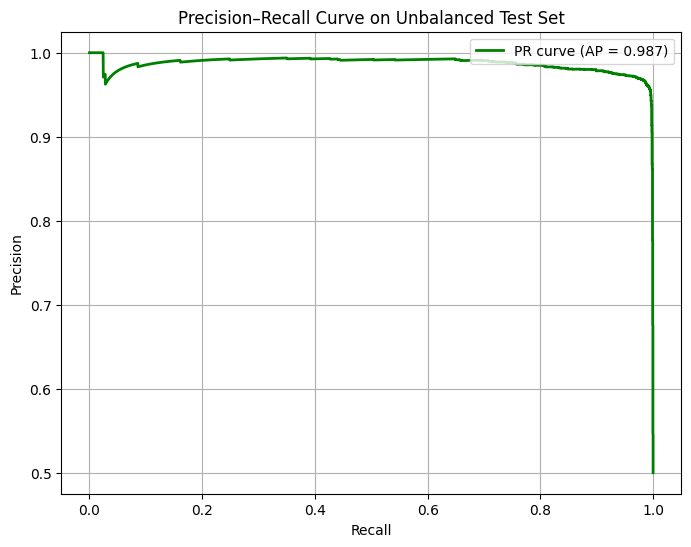

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, pr_thresholds = precision_recall_curve(y_true, y_scores)
pr_auc = average_precision_score(y_true, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR curve (AP = {pr_auc:.3f})', color='green', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve on Unbalanced Test Set')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

## Prediction for negative classification

In [ ]:
# Sample from remaining unlabeled
remaining_unlabeled = unlabeled.drop(unlabeled_sampled.index)
remaining_unlabeled = remaining_unlabeled.sample(frac=fraction_remaining_unlabeled, random_state=SEED)

remaining_unlabeled_texts = remaining_unlabeled["text_mining_description"].tolist()

remaining_unlabeled_dataset = Dataset.from_dict({'text': remaining_unlabeled_texts})
remaining_unlabeled_dataset = remaining_unlabeled_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/352290 [00:00<?, ? examples/s]

In [ ]:
# Returns Prediction Output
pred_output = trainer.predict(remaining_unlabeled_dataset)
logits = pred_output.predictions

probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

remaining_unlabeled["probability_is_gender"] = probs

In [ ]:
# Save to xlsx
remaining_unlabeled.to_excel("./drive/MyDrive/Colab Notebooks/unlabeled_predictions_gender.xlsx", index=False)

# Rebuild Training set with reliable negatives

In [ ]:
# Read remaining_unlabled from xlsx
remaining_unlabeled = pd.read_excel("./drive/MyDrive/Colab Notebooks/unlabeled_predictions_gender.xlsx")

In [ ]:
# --------------------------- Positives ----------------------------------------
# Filter out positive and unlabeled samples
positive = gen_to_mine[gen_to_mine['is_gender'] == True].copy()

# Sample randomly fraction_positives for positives
positive = positive.sample(frac=fraction_positives_for_tuning, random_state=SEED)

# Use the same stratum distribution as positives
positive.loc[:, 'length_bin'] = pd.cut(
    positive['text_mining_description'].str.len(), bins=6, labels=False, include_lowest=True
)
positive.loc[:, 'stratum'] = positive['language'].astype(str) + "_" + positive['length_bin'].astype(str)
stratum_counts = positive['stratum'].value_counts(normalize=True)

# ------------------------- Reliable negatives ---------------------------------
# Select reliable negatives: probability < 0.8 (stratum & language still present from earlier)
reliable_negatives = remaining_unlabeled[remaining_unlabeled['probability_is_gender'] < 0.8].copy()

samples_per_stratum = (stratum_counts * len(positive)).round().astype(int)

neg_samples = []
for stratum, n in samples_per_stratum.items():
    candidates = reliable_negatives[reliable_negatives['stratum'] == stratum]
    if len(candidates) >= n:
        neg_samples.append(candidates.sample(n=n, random_state=SEED))
    else:
        neg_samples.append(candidates)

reliable_negatives_sampled = pd.concat(neg_samples).sample(frac=1, random_state=SEED)
reliable_negatives_sampled = reliable_negatives_sampled.drop(columns=['probability_is_gender', 'length_bin', 'stratum'])

# Rebuild the training set
positive = positive.drop(columns=['length_bin', 'stratum'])
new_balanced = pd.concat([positive, reliable_negatives_sampled]).reset_index(drop=True)
new_balanced = new_balanced.drop(columns=['is_mining'], errors='ignore')

In [ ]:
new_balanced['is_gender'].value_counts()

,count
is_gender,
True,44062
False,43576


In [ ]:
# Save new balanced as csv
new_balanced.to_csv("./drive/MyDrive/Colab Notebooks/new_balanced.csv", index=False)

In [ ]:
# Load new balanced
new_balanced = pd.read_csv("./drive/MyDrive/Colab Notebooks/new_balanced.csv")

In [ ]:
# Split into train+val and test sets first (80% train+val, 20% test)
train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(
    new_balanced['text_mining_description'],
    new_balanced['is_gender'].astype(int),
    test_size=0.1,
    stratify=new_balanced['is_gender'],
    random_state=SEED
)

# Now split train+val into train and validation sets (75% train, 25% val of the 80%)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts,
    train_val_labels,
    test_size=1/9,  # 1/9 x 0.9 = 0.1, so final split is 80% train, 10% val, 10% test
    stratify=train_val_labels,
    random_state=SEED
)

In [ ]:
# Load tokenizer and tokenize data
tokenizer = AutoTokenizer.from_pretrained(model_id)

def tokenize(batch):
    return tokenizer(batch['text'], padding="max_length", truncation=True, max_length=max_token_length)

# Create Hugging Face datasets
train_dataset = Dataset.from_dict({'text': train_texts.tolist(), 'label': train_labels.tolist()})
val_dataset = Dataset.from_dict({'text': val_texts.tolist(), 'label': val_labels.tolist()})
test_dataset = Dataset.from_dict({'text': test_texts.tolist(), 'label': test_labels.tolist()})

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

# Set format for PyTorch
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

Map:   0%|          | 0/5288 [00:00<?, ? examples/s]

Map:   0%|          | 0/661 [00:00<?, ? examples/s]

Map:   0%|          | 0/661 [00:00<?, ? examples/s]

# Predict training set with model from checkpoint

In [ ]:
# Load best model from checkpoint
model_checkpoint = "./drive/MyDrive/Colab Notebooks/models/results/checkpoint-5688"  # Replace xxx with the last saved checkpoint

# Load model from checkpoint
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint)

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)
def tokenize(batch):
    return tokenizer(batch['text'], padding="max_length", truncation=True, max_length=max_token_length)

train_dataset = Dataset.from_dict({'text': new_balanced['text_mining_description'].tolist(), 'label': new_balanced['is_statistics'].tolist()})
train_dataset = train_dataset.map(tokenize, batched=True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Map:   0%|          | 0/25266 [00:00<?, ? examples/s]

In [ ]:
args = TrainingArguments(
    output_dir="./results",           # dummy
    per_device_eval_batch_size=128,
    do_train=False,
    do_eval=False,
    fp16=True,
    report_to="none",
    logging_strategy="no"
)

trainer = Trainer(
    model=model,
    args=args
)

In [ ]:
pred_output = trainer.predict(train_dataset)

In [ ]:
# Merge predictions back to training data set
new_balanced['probability_is_statistics'] = torch.softmax(torch.tensor(pred_output.predictions), dim=1)[:, 1].numpy()

new_balanced.to_excel("./drive/MyDrive/Colab Notebooks/training_set_predicted.xlsx", index=False)

# Hyperparameter tuning

## Ray Tune

In [ ]:
import ray
from ray import tune
from ray.tune import JupyterNotebookReporter
from ray.tune.schedulers import ASHAScheduler
from transformers import TrainerCallback

reporter = JupyterNotebookReporter(
    parameter_columns=["learning_rate", "per_device_train_batch_size"],
    metric_columns=["eval_accuracy", "eval_f1", "eval_auc", "eval_loss", "epoch"]
)

scheduler = ASHAScheduler(
        metric="accuracy", #loss defined in training function
        mode="max",
        grace_period=1, # iterations after which ASHA terminates if metric doesn't improve
        reduction_factor=10) # iterations after which ASHA reevaluates metric and determine to stop a trial

# Define metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

def compute_metrics(pred):
    labels = pred.label_ids
    logits = pred.predictions
    preds = np.argmax(logits, axis=-1)

    # Get probability for positive class (class 1)
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

    # Standard classification metrics
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)

    # Compute AUC (requires probabilities, not argmax predictions)
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        # In case only one class is present in labels
        auc = float('nan')

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "auc": auc
    }

class TuneReportCallback(TrainerCallback):
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics:
            # Report all available metrics (e.g., loss, accuracy, etc.)
            tune.report(metrics)

def model_init():
    return AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=2)

config = {
    "learning_rate": tune.uniform(1e-5, 5e-5),
    "weight_decay":  tune.uniform(0.0, 0.3),
    "num_train_epochs": tune.choice([2, 3, 4]),
    "per_device_train_batch_size": tune.choice([8, 16, 32]),
    "warmup_ratio": tune.choice([0.0, 0.06, 0.1]),
    "gradient_accumulation_steps": tune.choice([1, 2, 4]),
    "adam_beta1": tune.choice([0.9, 0.95]),
    "adam_beta2": tune.choice([0.98, 0.999]),
}

train_ref = ray.put(train_dataset)
val_ref = ray.put(val_dataset)

def trainer_init(config):
    output_dir = os.path.abspath("./models/results")

    args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=config["learning_rate"],
        per_device_train_batch_size=config["per_device_train_batch_size"],
        gradient_accumulation_steps = config["gradient_accumulation_steps"],
        num_train_epochs=config["num_train_epochs"],
        weight_decay=config["weight_decay"],
        warmup_ratio=config["warmup_ratio"],
        adam_beta1=config["adam_beta1"],
        adam_beta2=config["adam_beta2"],
        per_device_eval_batch_size=8,
        logging_dir="./models/logs",
        eval_strategy="epoch",
        save_strategy="no",
        load_best_model_at_end=False,
        metric_for_best_model="auc",
        report_to="none"
    )

    return Trainer(
        args=args,
        train_dataset=ray.get(train_ref),
        eval_dataset=ray.get(val_ref),
        compute_metrics=compute_metrics,
        model_init=model_init,
        callbacks=[TuneReportCallback()]
    )


def run_ray_train(config):
    trainer = trainer_init(config)
    trainer.train()
    eval_metrics = trainer.evaluate()
    tune.report(eval_metrics)

In [ ]:
import os
storage_path = os.path.abspath("./drive/MyDrive/Colab Notebooks/ray_tune_results/gender")

# Hyperparameter tuning with Ray Tune
analysis = tune.run(
    run_ray_train,
    config=config,
    resources_per_trial={"cpu": n_cpu_ray, "gpu": n_gpu_ray},
    metric="eval_accuracy",
    mode="max",
    num_samples=n_trials_ray,
    #scheduler=scheduler,
    progress_reporter=reporter,
    storage_path=storage_path,
    name="tune_xlm_roberta"
)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Best config
best_config_base = {
  "adam_beta1": 0.95,
  "adam_beta2": 0.98,
  "gradient_accumulation_steps": 2,
  "learning_rate": 3.5175945525410505e-05,
  "num_train_epochs": 4,
  "per_device_train_batch_size": 8,
  "warmup_ratio": 0.0,
  "weight_decay": 0.20872460669538515
}

best_config_large = {
  "adam_beta1": 0.9,
  "adam_beta2": 0.999,
  "gradient_accumulation_steps": 4,
  "learning_rate": 2.5023318105597762e-05,
  "num_train_epochs": 4,
  "per_device_train_batch_size": 32,
  "warmup_ratio": 0.06,
  "weight_decay": 0.028194581952260697
}

# Final classification

## Retraining with best config from hyperparameter search

In [ ]:
balanced['is_statistics'].value_counts()

,count
is_statistics,
False,14723
True,10954


In [ ]:
# Split into train+val and test sets first (80% train+val, 20% test)
train_texts, test_texts, train_labels, test_labels = train_test_split(
    new_balanced['text_mining_description'],
    new_balanced['is_gender'].astype(int),
    test_size=0.1,
    stratify=new_balanced['is_gender'],
    random_state=SEED
)

In [ ]:
# Augment validation set and test set with true negatives from reliable_negatives
n_pos_test = sum(test_labels)
n_neg_test = len(test_labels) - n_pos_test
n_neg_add_hyper_tuning = int((n_pos_test - fraction_positives_in_test*(n_pos_test + n_neg_test))/fraction_positives_in_test)

# Sample
additional_negatives_test = reliable_negatives.sample(n=n_neg_add_hyper_tuning, random_state=SEED)

# Get
test_texts = pd.concat([test_texts, additional_negatives_test['text_mining_description']])
test_labels =  pd.concat([test_labels, additional_negatives_test['is_statistics'].astype(int)])

print(f"Final test prevalence: {np.mean(test_labels)}")
print(f"Number of positives in test set: {sum(test_labels)}")

Final test prevalence: 0.1
Number of positives in test set: 1096


In [ ]:
# Load tokenizer and tokenize data
tokenizer = AutoTokenizer.from_pretrained(model_id)

def tokenize(batch):
    return tokenizer(batch['text'], padding="max_length", truncation=True, max_length=max_token_length)

# Create Hugging Face datasets
train_dataset = Dataset.from_dict({'text': train_texts.tolist(), 'label': train_labels.tolist()})
test_dataset = Dataset.from_dict({'text': test_texts.tolist(), 'label': test_labels.tolist()})

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

# Set format for PyTorch
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Map:   0%|          | 0/78874 [00:00<?, ? examples/s]

Map:   0%|          | 0/8764 [00:00<?, ? examples/s]

In [ ]:
# Load pre-trained model
model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=2)

best_config = best_config_large.copy()

# Define training arguments
training_args = TrainingArguments(
    output_dir="./drive/MyDrive/Colab Notebooks/models/results",
    num_train_epochs=best_config["num_train_epochs"],
    per_device_train_batch_size=best_config["per_device_train_batch_size"],
    per_device_eval_batch_size=64,
    gradient_accumulation_steps = best_config["gradient_accumulation_steps"],
    warmup_ratio=best_config["warmup_ratio"],
    weight_decay=best_config["weight_decay"],
    learning_rate=best_config["learning_rate"],
    adam_beta1=best_config["adam_beta1"],
    adam_beta2=best_config["adam_beta2"],
    logging_dir="./drive/MyDrive/Colab Notebooks/models/logs",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    save_total_limit=1, # keeps only the latest checkpoint
    metric_for_best_model="auc",
    fp16=True,
    report_to="none"
)

# Define metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

def compute_metrics(pred):
    labels = pred.label_ids
    logits = pred.predictions
    preds = np.argmax(logits, axis=-1)

    # Get probability for positive class (class 1)
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

    # Standard classification metrics
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)

    # Compute AUC (requires probabilities, not argmax predictions)
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        # In case only one class is present in labels
        auc = float('nan')

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "auc": auc
    }

# Trainer setup
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# Train the model
trainer.train()

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Auc
1,0.156900,0.054330,0.987791,0.987840,0.989301,0.986382,0.997094
2,0.045900,0.047911,0.990187,0.990218,0.992476,0.987971,0.998154
3,0.035300,0.036724,0.991100,0.991144,0.991595,0.990695,0.998904
4,0.023300,0.039708,0.991442,0.991492,0.991154,0.991829,0.998885


TrainOutput(global_step=2468, training_loss=0.0562492344329191, metrics={'train_runtime': 3367.641, 'train_samples_per_second': 93.685, 'train_steps_per_second': 0.733, 'total_flos': 2.940206174045307e+17, 'train_loss': 0.0562492344329191, 'epoch': 4.0})

In [ ]:
# Evaluate or resume training
predictions_output = trainer.predict(test_dataset)

# Output test set with, text, label, and predicted probabilities
test_results = pd.DataFrame({
    'text': test_texts,
    'label': test_labels,
    'probability_is_statistics': torch.softmax(torch.tensor(predictions_output.predictions), dim=1)[:, 1].numpy()
})

In [ ]:
test_results.to_excel("./drive/MyDrive/Colab Notebooks/test_set_predicted_gen.xlsx", index=False)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
import plotly.graph_objs as go

# Extract labels and predicted probabilities
y_true = test_results['label'].values
y_scores = test_results['probability_is_statistics'].values

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = roc_auc_score(y_true, y_scores)

# Build interactive ROC plot
hover_text = [f"Threshold: {thr:.3f}<br>FPR: {f:.3f}<br>TPR: {t:.3f}"
              for thr, f, t in zip(thresholds, fpr, tpr)]

trace = go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines+markers',
    text=hover_text,
    hoverinfo='text',
    name=f'ROC curve (AUC = {roc_auc:.3f})',
    line=dict(color='orange')
)

line_random = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random Guessing',
    line=dict(dash='dash', color='navy')
)

layout = go.Layout(
    title='ROC Curve',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate (Recall)'),
    legend=dict(x=0.6, y=0.05),
    hovermode='closest'
)

fig = go.Figure(data=[trace, line_random], layout=layout)
fig.show()


## Final predictions of unlabeled data

In [ ]:
# Load best model from checkpoint
model_checkpoint = "./drive/MyDrive/Colab Notebooks/models/results/large-checkpoint-2169"  # Replace with the last saved checkpoint

# Load model from checkpoint
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint)

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)
def tokenize(batch):
    return tokenizer(batch['text'], padding="max_length", truncation=True, max_length=max_token_length)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [ ]:
unlabeled_texts = unlabeled["text_mining_description"].tolist()

unlabeled_dataset = Dataset.from_dict({'text': unlabeled_texts})
unlabeled_dataset = unlabeled_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/1788685 [00:00<?, ? examples/s]

In [ ]:
# Load conflicting descriptions from conflicting_descr_stats
conflicting_gen = pd.read_feather("./drive/MyDrive/Colab Notebooks/conflicting_descr_gen.feather")

conflicting_gen_texts = conflicting_gen["text_mining_description"].tolist()

conflicting_gen_dataset = Dataset.from_dict({'text': conflicting_gen_texts})
conflicting_gen_dataset = conflicting_gen_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/1813 [00:00<?, ? examples/s]

In [ ]:
# Load additional after update
additional_after_update = pd.read_feather("./drive/MyDrive/Colab Notebooks/added_after_update.feather")

additional_after_update_texts = additional_after_update["text_mining_description"].tolist()

additional_after_update_dataset = Dataset.from_dict({'text': additional_after_update_texts})
additional_after_update_dataset = additional_after_update_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/9335 [00:00<?, ? examples/s]

In [ ]:
args = TrainingArguments(
    output_dir="./results",           # dummy
    per_device_eval_batch_size=128,
    do_train=False,
    do_eval=False,
    fp16=True,
    report_to="none",
    logging_strategy="no"
)

trainer = Trainer(
    model=model,
    args=args
)

In [ ]:
pred_output = trainer.predict(unlabeled_dataset)

# Probabilities
logits = pred_output.predictions
probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

# Assign it to the new column
unlabeled['probability_is_gender'] = probs

In [ ]:
# Save to feather
unlabeled.to_feather("./drive/MyDrive/Colab Notebooks/unlabeled_predicted_gen.feather")

In [ ]:
pred_output_conflicting = trainer.predict(conflicting_gen_dataset)

# Probabilities
logits_conflicting = pred_output_conflicting.predictions
probs_conflicting = torch.softmax(torch.tensor(logits_conflicting), dim=1)[:, 1].numpy()

conflicting_gen['probability_is_statistics'] = probs_conflicting

conflicting_gen.to_feather("./drive/MyDrive/Colab Notebooks/conflicting_gen_predicted_large.feather")

In [ ]:
pred_output_added = trainer.predict(additional_after_update_dataset)

# Probabilities
logits_added = pred_output_added.predictions
probs_added = torch.softmax(torch.tensor(logits_added), dim=1)[:, 1].numpy()

additional_after_update['probability_is_gender'] = probs_added

additional_after_update.to_feather("./drive/MyDrive/Colab Notebooks/added_after_update_predicted.feather")

# Interpretability (Under development!!)

In [ ]:
!pip install -q transformers captum torch

In [ ]:
import pandas as pd

unlabeled_sampled = pd.read_excel("./drive/MyDrive/Colab Notebooks/unlabeled_predicted.xlsx")

In [ ]:
# Get the 20 highest and lowest ranking from unlabeled_sampled
unlabeled_sampled = unlabeled_sampled.sort_values(by='probability_is_statistics', ascending=False)
highest_prob_unlabeled = unlabeled_sampled.head(10)
lowest_prob_unlabeled = unlabeled_sampled.head(-10)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from captum.attr import IntegratedGradients
from captum.attr import LayerIntegratedGradients
from captum.attr import visualization as viz
import numpy as np

# Pick ANY text‑classification model
model_id = "xlm-roberta-base"          # or "distilbert-base-uncased-finetuned-sst-2-english"
model_checkpoint = "./drive/MyDrive/Colab Notebooks/models/results/checkpoint-7581"
tokenizer  = AutoTokenizer.from_pretrained(model_id)
model      = AutoModelForSequenceClassification.from_pretrained(model_checkpoint)
model.eval()

text = highest_prob_unlabeled.iloc[0]['text_mining_description']

# Encode the text
enc = tokenizer(text, return_tensors="pt")
input_ids = enc["input_ids"]
attn_mask = enc["attention_mask"]

target = model(**enc).logits.argmax(-1).item()

# pick the embedding layer
emb_layer = model.roberta.embeddings

lig = LayerIntegratedGradients(
        lambda ids, mask: model(input_ids=ids, attention_mask=mask).logits,
        emb_layer)

# compute attributions
attr, _ = lig.attribute(inputs=input_ids,
                        additional_forward_args=attn_mask,
                        target=target,
                        return_convergence_delta=True)

# sum over hidden dim
scores = attr.sum(-1).squeeze(0)
scores = scores / scores.abs().sum()

for tok_id, score in zip(input_ids[0], scores):
    print(f"{tokenizer.convert_ids_to_tokens(int(tok_id)):>12} : {score.item():+.3f}")

In [ ]:
text = unlabeled_sampled.iloc[1]['text_mining_description']

enc = tokenizer(text, return_tensors="pt")
input_ids, attn_mask = enc["input_ids"], enc["attention_mask"]

# ▬▬▬ 3. choose target label ▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬
with torch.no_grad():
    logits = model(**enc).logits
probs  = logits.softmax(-1)[0]
pred   = probs.argmax().item()

emb_layer = model.roberta.embeddings  # for BERT use model.bert.embeddings, for XLM‑R model.roberta…

lig = LayerIntegratedGradients(
        lambda ids, mask: model(input_ids=ids,
                                attention_mask=mask).logits,
        emb_layer)

attributions, delta = lig.attribute(inputs=input_ids,
                                additional_forward_args=attn_mask,
                                target=pred,
                                return_convergence_delta=True)

# collapse embedding dim → one score per token
attr_scores = attributions.sum(-1).squeeze(0)
attr_scores = attr_scores / attr_scores.abs().sum()

tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

# ▬▬▬ 5. Captum visualisation record ▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬▬
vis_data = viz.VisualizationDataRecord(
                attr_scores.detach().cpu().numpy(),
                probs[pred].item(),          # predicted prob
                pred,                        # predicted class idx
                pred,                        # true class idx (use your label here)
                "class_" + str(pred),        # class name (string)
                attr_scores.sum().item(),    # total attribution
                tokens,                      # list of tokens
                delta
          )

viz.visualize_text([vis_data])

In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification, BertConfig
from captum.attr import visualization as viz
from captum.attr import IntegratedGradients, LayerConductance, LayerIntegratedGradients
from captum.attr import configure_interpretable_embedding_layer, remove_interpretable_embedding_layer
import torch
import matplotlib.pyplot as plt

import captum

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Pick ANY text‑classification model
model_id = "xlm-roberta-base"          # or "distilbert-base-uncased-finetuned-sst-2-english"
model_checkpoint = "./drive/MyDrive/Colab Notebooks/models/results/checkpoint-7581"
tokenizer  = AutoTokenizer.from_pretrained(model_id)
model      = AutoModelForSequenceClassification.from_pretrained(model_checkpoint)
model.to(device)
model.eval()

def predict(inputs):
    #print('model(inputs): ', model(inputs))
    return model(inputs)[0]

ref_token_id = tokenizer.pad_token_id # A token used for generating token reference
sep_token_id = tokenizer.sep_token_id # A token used as a separator between question and text and it is also added to the end of the text.
cls_token_id = tokenizer.cls_token_id # A token used for prepending to the concatenated question-text word sequence

In [ ]:
def construct_input_ref_pair(text, ref_token_id, sep_token_id, cls_token_id):

    text_ids = tokenizer.encode(text, add_special_tokens=False)
    # construct input token ids
    input_ids = [cls_token_id] + text_ids + [sep_token_id]
    # construct reference token ids
    ref_input_ids = [cls_token_id] + [ref_token_id] * len(text_ids) + [sep_token_id]

    return torch.tensor([input_ids], device=device), torch.tensor([ref_input_ids], device=device), len(text_ids)

def construct_input_ref_token_type_pair(input_ids, sep_ind=0):
    seq_len = input_ids.size(1)
    token_type_ids = torch.tensor([[0 if i <= sep_ind else 1 for i in range(seq_len)]], device=device)
    ref_token_type_ids = torch.zeros_like(token_type_ids, device=device)# * -1
    return token_type_ids, ref_token_type_ids

def construct_input_ref_pos_id_pair(input_ids):
    seq_length = input_ids.size(1)
    position_ids = torch.arange(seq_length, dtype=torch.long, device=device)
    # we could potentially also use random permutation with `torch.randperm(seq_length, device=device)`
    ref_position_ids = torch.zeros(seq_length, dtype=torch.long, device=device)

    position_ids = position_ids.unsqueeze(0).expand_as(input_ids)
    ref_position_ids = ref_position_ids.unsqueeze(0).expand_as(input_ids)
    return position_ids, ref_position_ids

def construct_attention_mask(input_ids):
    return torch.ones_like(input_ids)

def custom_forward(inputs):
    preds = predict(inputs)
    return torch.softmax(preds, dim = 1)[:, 0] # for negative attribution, torch.softmax(preds, dim = 1)[:, 1] <- for positive attribution

lig = LayerIntegratedGradients(custom_forward, model.roberta.embeddings)

In [ ]:
text = unlabeled_sampled.iloc[1]['text_mining_description']

In [ ]:
input_ids, ref_input_ids, sep_id = construct_input_ref_pair(text, ref_token_id, sep_token_id, cls_token_id)
token_type_ids, ref_token_type_ids = construct_input_ref_token_type_pair(input_ids, sep_id)
position_ids, ref_position_ids = construct_input_ref_pos_id_pair(input_ids)
attention_mask = construct_attention_mask(input_ids)

indices = input_ids[0].detach().tolist()
all_tokens = tokenizer.convert_ids_to_tokens(indices)

def save_act(module, inp, out):
  #global saved_act
  #saved_act = out
  return saved_act

hook = model.roberta.embeddings.register_forward_hook(save_act)

In [ ]:
hook.remove()

custom_forward(torch.cat([input_ids]))
input_ids.shape

torch.Size([1, 123])

In [ ]:
pred = predict(input_ids)
torch.softmax(pred, dim = 1)

tensor([[5.6806e-05, 9.9994e-01]], device='cuda:0', grad_fn=<SoftmaxBackward0>)

In [ ]:
attributions_main, delta_main = lig.attribute(inputs=input_ids,
                                    baselines=ref_input_ids,
                                    n_steps=3000,
                                    internal_batch_size=3,
                                    return_convergence_delta=True)

attributions, delta = lig.attribute(inputs=input_ids,
                                    baselines=ref_input_ids,
                                    n_steps=3000,
                                    internal_batch_size=5,
                                    return_convergence_delta=True)

In [ ]:
score = predict(input_ids)

print('Description: ', text)
print('Class: ' + str(torch.argmax(score[0]).cpu().numpy()) + \
      ', Probability positive: ' + str(torch.softmax(score, dim = 1)[0][1].cpu().detach().numpy()))

Description:  HOST COUNTRY STRATEGIC INFORMATION CAPACITY (BASIC ED): Establish and/or strengthen host country institutions management information systems (MIS) and their development and use of tools and models to collect analyze and disseminate a variety of information related to the program element. These may include but are not limited to MIS for government ministries or other host country institutions needs assessments baseline studies censuses and surveys targeted evaluations special studies routine surveillance data quality assessments and operati [Government of Malawi]
Class: 1, Probability positive: 0.99994314


In [ ]:
def summarize_attributions(attributions):
    attributions = attributions.sum(dim=-1).squeeze(0)
    attributions = attributions / torch.norm(attributions)
    return attributions

attributions_sum = summarize_attributions(attributions)

In [ ]:
# storing couple samples in an array for visualization purposes
score_vis = viz.VisualizationDataRecord(attributions_sum,
                                        torch.softmax(score, dim = 1)[0][0],
                                        torch.argmax(torch.softmax(score, dim = 1)[0]),
                                        1,
                                        text,
                                        attributions_sum.sum(),
                                        all_tokens,
                                        delta)

print('\033[1m', 'Visualization For Score', '\033[0m')
viz.visualize_text([score_vis])

 Visualization For Score 
